# Noah meeting prep — May 28 2026

Top-line deliverables:
1. **Headline graph**: per-task AUC for dense Llama-8B (aggregated across trials) vs code-only vs code+LLM-judge
2. **Top correlated metrics per task** — code metrics, then judge metrics
3. **Per-task distribution** of high-correlation metrics (does CW have more useful judge metrics than math?)

In [1]:
import json, re, gzip, os
from pathlib import Path
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

# Always anchor on the repo root regardless of cwd
REPO = Path('/Users/spangher/Projects/stanford-research/norm-research')
assert (REPO / 'outputs').exists(), f'no outputs dir under {REPO}'
os.chdir(REPO)

TASKS = ['peer_review', 'math', 'notice_and_comment', 'press_releases',
         'humor', 'news_homepages', 'patents', 'code_review', 'creative_writing']

DENSE_DIRS = {
    'peer_review':       'peer_review_sweep_llama8b',
    'math':              'math_se_sweep_llama8b',
    'notice_and_comment':'notice_and_comment_sweep_llama8b',
    'press_releases':    'press_release_clean_sweep_llama8b',
    'humor':             'reddit_humor_sweep_llama8b',
    'news_homepages':    'homepage_newsworthiness_sweep_llama8b',
    'patents':           'patents_first_draft_baseline_sweep_llama8b',
    'code_review':       'code_review_sweep_llama8b',
    'creative_writing':  'creative_writing_sweep_llama8b',
}

OUT = REPO / 'outputs/noah_meeting'
OUT.mkdir(parents=True, exist_ok=True)
print(f'REPO: {REPO}')
print(f'cwd:  {os.getcwd()}')

REPO: /Users/spangher/Projects/stanford-research/norm-research
cwd:  /Users/spangher/Projects/stanford-research/norm-research


## 1. Load data per task

In [2]:
def load_judge_db(task, judge):
    for ext in ['parquet', 'csv.gz']:
        p = REPO / f'outputs/v2_db/cells_v1/task={task}/judge={judge}/data.{ext}'
        if p.exists():
            df = pd.read_parquet(p) if ext == 'parquet' else pd.read_csv(p, compression='gzip')
            if 'parse_status' in df.columns:
                df = df[df['parse_status'] == 'ok']
            return df
    return None

def load_labels(task):
    d = json.load(open(REPO / f'runs/validity_full/v2/{task}/datapoints.json'))
    return pd.DataFrame([{'datapoint_id': r['datapoint_id'], 'y': r['judgement']} for r in d])

def load_code_scores(task):
    p = REPO / f'runs/validity_full/v2/{task}/codegen_exec_results.jsonl'
    if not p.exists():
        return None
    rows = [json.loads(l) for l in open(p)]
    return pd.DataFrame(rows)

data = {}
for t in TASKS:
    qwen = load_judge_db(t, 'qwen_thinking_fp8_20x1_r2post')
    qwen_p0 = qwen[qwen['paraphrase_idx'] == 0] if qwen is not None else None
    labels = load_labels(t)
    code = load_code_scores(t)
    data[t] = {'qwen': qwen_p0, 'labels': labels, 'code': code}
    print(f'{t:<22} labels={len(labels):>5} | qwen_p0={len(qwen_p0) if qwen_p0 is not None else 0:>7} | code={len(code) if code is not None else 0:>6}')

peer_review            labels= 4999 | qwen_p0=  45552 | code=2849430


math                   labels= 5000 | qwen_p0=  52321 | code=3645000


notice_and_comment     labels= 5000 | qwen_p0=  46866 | code=2985000


press_releases         labels= 5000 | qwen_p0=  34783 | code=3975000


humor                  labels= 5000 | qwen_p0=  51582 | code=5490000


news_homepages         labels= 5000 | qwen_p0=  35200 | code=3105000


patents                labels= 5000 | qwen_p0=  23398 | code=2835000


code_review            labels= 5000 | qwen_p0=  59384 | code=5910000


creative_writing       labels= 5000 | qwen_p0=  42475 | code=4815000


## 2. Build dp × feature matrices for code and judge

In [3]:
def pivot_judge(df):
    """long → wide: dp × aspect, score. drop non-applicable (score null)."""
    if df is None or df.empty:
        return pd.DataFrame()
    d = df.copy()
    if 'applicable' in d.columns:
        d = d[d['applicable'].astype(str).str.lower() != 'false']
    d = d[d['score'].notna()]
    return d.pivot_table(index='datapoint_id', columns='aspect_id', values='score', aggfunc='mean')

def pivot_code(df, by_variant=False):
    """Code-exec results → wide. Columns: aspect_id, variant, datapoint_id, score, error.
    If by_variant=True, expand each (aspect, variant) into its own column."""
    if df is None or df.empty:
        return pd.DataFrame()
    d = df[['datapoint_id', 'aspect_id', 'variant', 'score']].copy()
    d['score'] = pd.to_numeric(d['score'], errors='coerce')
    d = d.dropna(subset=['score'])
    if by_variant:
        d['feature'] = d['aspect_id'].astype(str) + '__' + d['variant'].astype(str)
    else:
        # Aggregate across variants per (aspect, dp): mean score
        d['feature'] = d['aspect_id'].astype(str)
    return d.pivot_table(index='datapoint_id', columns='feature', values='score', aggfunc='mean')

wide = {}
for t in TASKS:
    wj = pivot_judge(data[t]['qwen'])
    wc = pivot_code(data[t]['code'], by_variant=False)
    wide[t] = {'judge': wj, 'code': wc}
    print(f'{t:<22} judge: {wj.shape}  code: {wc.shape}')

peer_review            judge: (800, 193)  code: (4999, 190)


math                   judge: (897, 200)  code: (5000, 244)


notice_and_comment     judge: (913, 144)  code: (5000, 199)


press_releases         judge: (811, 242)  code: (5000, 268)


humor                  judge: (848, 253)  code: (5000, 366)


news_homepages         judge: (838, 160)  code: (5000, 207)


patents                judge: (798, 95)  code: (5000, 189)


code_review            judge: (838, 340)  code: (5000, 394)


creative_writing       judge: (815, 282)  code: (5000, 321)


## 3. Dense AUC — aggregate across trials

Per task: read all `validation_metrics.csv` files in subset_1p0 (full-data) runs, take **max val_auc per trial** (best epoch), then aggregate (mean ± std) across trials.

In [4]:
def _subset_frac(name):
    """subset_1p0 → 1.0; subset_0_9 → 0.9; subset_0.5 → 0.5"""
    m = re.search(r'subset_([0-9p._]+)', name)
    if not m:
        return None
    s = m.group(1).replace('p', '.').replace('_', '.')
    try:
        return float(s)
    except ValueError:
        return None

def _trial_aucs_from_dir(sd):
    """Collect non-NaN max val_aucs from a subset dir (direct csv + each trial subdir)."""
    aucs = []
    direct = sd / 'validation_metrics.csv'
    if direct.exists():
        df = pd.read_csv(direct)
        if 'val_auc' in df.columns:
            v = df['val_auc'].max()
            if pd.notna(v):
                aucs.append(float(v))
    for trial in sd.iterdir():
        if trial.is_dir():
            vm = trial / 'validation_metrics.csv'
            if vm.exists():
                df = pd.read_csv(vm)
                if 'val_auc' in df.columns:
                    v = df['val_auc'].max()
                    if pd.notna(v):
                        aucs.append(float(v))
    return aucs

def get_dense_trial_aucs(task):
    """Return (subset_frac, [val_auc per trial]) for the LARGEST subset that has valid AUCs."""
    dense_dir = DENSE_DIRS.get(task)
    if not dense_dir:
        return (None, [])
    base = REPO / 'runs' / dense_dir
    if not base.exists():
        return (None, [])
    subsets = [(p, _subset_frac(p.name)) for p in base.iterdir() if p.is_dir() and p.name.startswith('subset_')]
    subsets = sorted([(p, f) for p, f in subsets if f is not None], key=lambda x: -x[1])  # largest first
    for sd, frac in subsets:
        aucs = _trial_aucs_from_dir(sd)
        if aucs:
            return (frac, aucs)
    return (None, [])

dense = []
for t in TASKS:
    frac, aucs = get_dense_trial_aucs(t)
    dense.append({
        'task': t,
        'dense_mean': np.mean(aucs) if aucs else None,
        'dense_std': np.std(aucs) if aucs else None,
        'dense_n_trials': len(aucs),
        'dense_max': max(aucs) if aucs else None,
        'dense_subset': frac,
    })
dense_df = pd.DataFrame(dense)
dense_df.round(3)

,task,dense_mean,dense_std,dense_n_trials,dense_max,dense_subset
0,peer_review,0.771,0.007,5,0.780,1.0
1,math,0.825,0.000,1,0.825,0.6
2,notice_and_comment,0.770,0.015,2,0.785,0.9
3,press_releases,0.679,0.000,1,0.679,1.0
4,humor,0.824,0.000,1,0.824,0.7
5,news_homepages,0.856,0.000,1,0.856,0.8
6,patents,0.744,0.000,1,0.744,0.4
7,code_review,0.786,0.000,1,0.786,1.0
8,creative_writing,0.820,0.101,5,0.904,1.0


## 4. Code-only AUC, code+judge AUC per task

In [5]:
def cv_auc(X, y, n_splits=5, C=0.5, min_dps=30, min_features=2, missing_indicator=True):
    """Cross-validated AUC. X = dp×feature, y indexed on same dps.
    Missing-as-NaN cells get filled with column median (within-source imputation),
    and optionally an indicator col is added so the model can learn 'this aspect wasn't scored'.
    Drops features that are 100% NaN. Keeps ALL rows (no dp dropping)."""
    if X.empty or len(y) < min_dps:
        return None
    keep = X.columns[X.notna().any()]
    if len(keep) < min_features:
        return None
    Xv = X[keep].copy()
    if missing_indicator:
        miss = Xv.isna().astype(int)
        miss = miss.loc[:, (miss.sum(axis=0) > 0) & (miss.sum(axis=0) < len(miss))]
        miss.columns = [f'{c}__missing' for c in miss.columns]
        Xv = pd.concat([Xv, miss], axis=1)
    Xv = Xv.fillna(Xv.median())
    Xv = Xv.fillna(0)
    Xv_arr = StandardScaler().fit_transform(Xv.values)
    yv = y.loc[X.index].values
    if pd.Series(yv).nunique() < 2:
        return None
    if min(np.bincount(yv.astype(int))) < n_splits:
        return None
    try:
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
        preds = np.full(len(yv), np.nan)
        for tr, te in skf.split(Xv_arr, yv):
            lr = LogisticRegression(C=C, penalty='l2', max_iter=2000, class_weight='balanced')
            lr.fit(Xv_arr[tr], yv[tr])
            preds[te] = lr.predict_proba(Xv_arr[te])[:, 1]
        return roc_auc_score(yv, preds), int(len(yv)), int(Xv.shape[1])
    except Exception:
        return None

# Same-dp-set treatment: use dps where we have at least SOME judge coverage. This is the
# panel we care about for the LLM-judge comparison (~800-900 per task). Within that panel,
# missing aspect cells are imputed (median + indicator), so no dp is dropped due to partial
# coverage within source.
rows = []
for t in TASKS:
    labels = data[t]['labels'].set_index('datapoint_id')['y']
    wc_raw = wide[t]['code']
    wj_raw = wide[t]['judge']
    
    judge_dps = wj_raw.index if not wj_raw.empty else pd.Index([])
    common = labels.index.intersection(judge_dps)
    if len(common) < 30:
        rows.append({'task': t, 'n_common': len(common)})
        continue
    
    y_common = labels.loc[common]
    wc_full = wc_raw.reindex(common) if not wc_raw.empty else pd.DataFrame(index=common)
    wj_full = wj_raw.reindex(common) if not wj_raw.empty else pd.DataFrame(index=common)
    joint = pd.concat([wc_full.add_prefix('CODE_'), wj_full.add_prefix('JUD_')], axis=1)
    
    code_res  = cv_auc(wc_full, y_common)  if not wc_full.empty  else None
    judge_res = cv_auc(wj_full, y_common)  if not wj_full.empty  else None
    joint_res = cv_auc(joint,  y_common)
    
    rows.append({
        'task': t,
        'n_common':       int(len(common)),
        'n_judge_dps':    int(len(judge_dps)),
        'code_auc':       code_res[0] if code_res else None,
        'code_k':         code_res[2] if code_res else 0,
        'judge_auc':      judge_res[0] if judge_res else None,
        'judge_k':        judge_res[2] if judge_res else 0,
        'codejudge_auc':  joint_res[0] if joint_res else None,
        'codejudge_k':    joint_res[2] if joint_res else 0,
    })
rep_df = pd.DataFrame(rows)
auc_df = rep_df.merge(dense_df, on='task', how='left')
auc_df.round(3)

,task,n_common,n_judge_dps,code_auc,code_k,judge_auc,judge_k,codejudge_auc,codejudge_k,dense_mean,dense_std,dense_n_trials,dense_max,dense_subset
0,peer_review,799,800,0.560,190,0.512,386,0.541,576,0.771,0.007,5,0.780,1.0
1,math,895,897,0.509,244,0.606,398,0.575,642,0.825,0.000,1,0.825,0.6
2,notice_and_comment,911,913,0.559,199,0.547,288,0.538,487,0.770,0.015,2,0.785,0.9
3,press_releases,810,811,0.525,268,0.512,484,0.525,752,0.679,0.000,1,0.679,1.0
4,humor,847,848,0.574,366,0.558,504,0.564,870,0.824,0.000,1,0.824,0.7
5,news_homepages,837,838,0.525,207,0.483,320,0.522,527,0.856,0.000,1,0.856,0.8
6,patents,797,798,0.567,189,0.510,190,0.528,379,0.744,0.000,1,0.744,0.4
7,code_review,837,838,0.535,394,0.503,680,0.518,1074,0.786,0.000,1,0.786,1.0
8,creative_writing,813,815,0.496,321,0.546,564,0.520,885,0.820,0.101,5,0.904,1.0


## 5. **HEADLINE GRAPH** — dense / code / code+judge per task

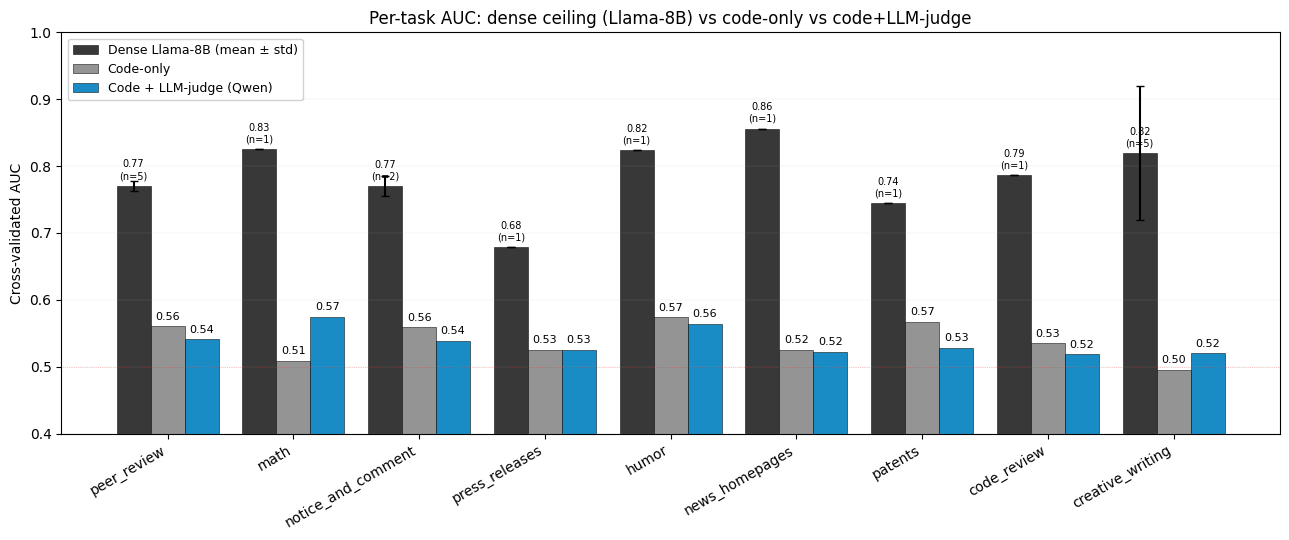

In [6]:
fig, ax = plt.subplots(figsize=(13, 5.5))
x = np.arange(len(auc_df))
w = 0.27

# Dense — with error bars across trials
dvals = auc_df['dense_mean'].values
dstd  = auc_df['dense_std'].values
dn    = auc_df['dense_n_trials'].values
ax.bar(x - w, np.nan_to_num(dvals), w, yerr=np.nan_to_num(dstd), label='Dense Llama-8B (mean ± std)',
       color='#222', alpha=0.9, edgecolor='black', linewidth=0.4, capsize=3)
for j, (v, n) in enumerate(zip(dvals, dn)):
    if v and not np.isnan(v):
        ax.text(x[j] - w, v + 0.01, f'{v:.2f}\n(n={n})', ha='center', fontsize=7)

# Code-only
cvals = auc_df['code_auc'].fillna(0).values
ax.bar(x, cvals, w, label='Code-only', color='#888', alpha=0.9, edgecolor='black', linewidth=0.4)
for j, v in enumerate(cvals):
    if v > 0:
        ax.text(x[j], v + 0.01, f'{v:.2f}', ha='center', fontsize=8)

# Code + Judge
jvals = auc_df['codejudge_auc'].fillna(0).values
ax.bar(x + w, jvals, w, label='Code + LLM-judge (Qwen)', color='#0080c0', alpha=0.9, edgecolor='black', linewidth=0.4)
for j, v in enumerate(jvals):
    if v > 0:
        ax.text(x[j] + w, v + 0.01, f'{v:.2f}', ha='center', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(auc_df['task'].values, rotation=30, ha='right')
ax.set_ylabel('Cross-validated AUC')
ax.set_ylim(0.4, 1.0)
ax.axhline(0.5, color='red', linewidth=0.5, linestyle=':', alpha=0.4)
ax.set_title('Per-task AUC: dense ceiling (Llama-8B) vs code-only vs code+LLM-judge')
ax.legend(loc='upper left', framealpha=0.9, fontsize=9)
ax.grid(axis='y', linewidth=0.3, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT / 'headline_aucs.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Top-correlated code metrics per task

Per (task, code_metric): |ρ(metric, label)|. Show top-K per task.

In [7]:
def metric_correlations(W, labels):
    """For each column of W, compute Pearson ρ vs labels (intersection of dps)."""
    rows = []
    if W.empty:
        return pd.DataFrame()
    common = W.index.intersection(labels.index)
    if len(common) < 30:
        return pd.DataFrame()
    y2 = labels.loc[common]
    W2 = W.loc[common]
    for col in W2.columns:
        s = W2[col].dropna()
        if len(s) < 30:
            continue
        yloc = y2.loc[s.index]
        if yloc.nunique() < 2:
            continue
        rho = s.corr(yloc)
        if rho is None or np.isnan(rho):
            continue
        rows.append({'aspect_id': col, 'rho': rho, 'abs_rho': abs(rho), 'n': len(s)})
    return pd.DataFrame(rows).sort_values('abs_rho', ascending=False)

code_rho = {}
judge_rho = {}
for t in TASKS:
    labels = data[t]['labels'].set_index('datapoint_id')['y']
    code_rho[t] = metric_correlations(wide[t]['code'], labels)
    judge_rho[t] = metric_correlations(wide[t]['judge'], labels)

# Show top-10 code metrics per task
print('=== TOP 10 CODE METRICS PER TASK (by |ρ|) ===\n')
for t in TASKS:
    df = code_rho[t]
    if df.empty:
        print(f'{t}: no code metrics\n')
        continue
    print(f'--- {t} ---')
    print(df.head(10).round(3).to_string(index=False))
    print()

/Users/spangher/miniconda3/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/spangher/miniconda3/lib/python3.12/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


=== TOP 10 CODE METRICS PER TASK (by |ρ|) ===

--- peer_review ---
aspect_id   rho  abs_rho    n
       a6 0.236    0.236 4999
     a106 0.227    0.227 4999
      a71 0.226    0.226 4999
     a101 0.226    0.226 4999
      a55 0.224    0.224 4999
       a5 0.223    0.223 4999
     a102 0.214    0.214 4999
     a161 0.210    0.210 4999
     a181 0.204    0.204 4999
     a198 0.203    0.203 4999

--- math ---
aspect_id   rho  abs_rho    n
     a224 0.101    0.101 5000
     a225 0.081    0.081 5000
      a25 0.080    0.080 5000
     a103 0.079    0.079 5000
       a8 0.073    0.073 5000
      a32 0.073    0.073 5000
      a47 0.071    0.071 5000
     a210 0.067    0.067 5000
     a146 0.063    0.063 5000
      a43 0.059    0.059 5000

--- notice_and_comment ---
aspect_id    rho  abs_rho    n
      a71 -0.110    0.110 5000
     a105 -0.088    0.088 5000
      a67 -0.077    0.077 5000
     a145 -0.071    0.071 5000
     a120 -0.062    0.062 5000
     a154 -0.061    0.061 5000
     a164  0.0

In [8]:
print('=== TOP 10 JUDGE METRICS PER TASK (by |ρ|) ===\n')
for t in TASKS:
    df = judge_rho[t]
    if df.empty:
        print(f'{t}: no judge metrics\n')
        continue
    print(f'--- {t} ---')
    print(df.head(10).round(3).to_string(index=False))
    print()

=== TOP 10 JUDGE METRICS PER TASK (by |ρ|) ===

--- peer_review ---
aspect_id   rho  abs_rho   n
       a0 0.393    0.393  45
      a60 0.254    0.254 219
      a53 0.252    0.252  57
     a181 0.233    0.233 160
      a66 0.208    0.208  74
      a12 0.205    0.205  43
     a194 0.205    0.205 171
      a91 0.200    0.200  50
     a165 0.189    0.189  43
     a156 0.184    0.184 194

--- math ---
aspect_id   rho  abs_rho   n
      a95 0.353    0.353 152
     a154 0.348    0.348 104
      a26 0.341    0.341 411
      a24 0.334    0.334 406
      a71 0.326    0.326 151
     a114 0.320    0.320 167
      a28 0.320    0.320 427
      a37 0.301    0.301 364
     a105 0.299    0.299 147
      a98 0.298    0.298 179

--- notice_and_comment ---
aspect_id    rho  abs_rho   n
      a86  0.376    0.376  31
      a51  0.233    0.233  52
      a85  0.228    0.228  34
      a68 -0.191    0.191  49
      a75  0.181    0.181  33
      a28 -0.152    0.152  52
      a88  0.137    0.137  51
     a141  0

## 7. Per-task distribution: how many useful metrics?

Hypothesis: creative_writing (more tacit) has FEWER metrics with high |ρ| than math (more structured). Plot histogram of |ρ| per task for code metrics, then for judge metrics.

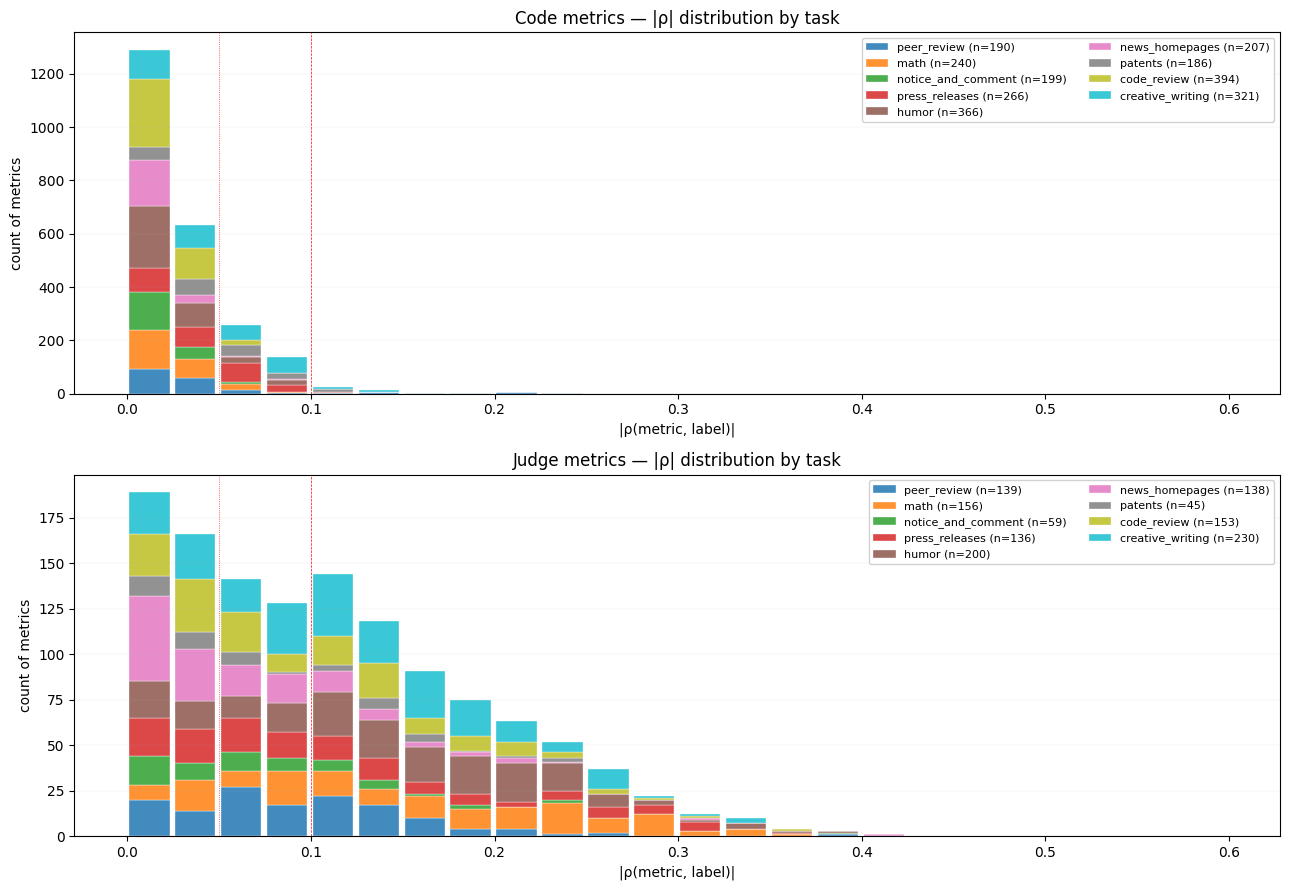

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(13, 9))

for ax, (label, rho_dict, color_seed) in zip(axes, [
    ('Code metrics — |ρ| distribution by task', code_rho, 'tab10'),
    ('Judge metrics — |ρ| distribution by task', judge_rho, 'tab10'),
]):
    bins = np.linspace(0, 0.6, 25)
    bottom = np.zeros(len(bins) - 1)
    cmap = plt.cm.tab10(np.linspace(0, 1, len(TASKS)))
    handles = []
    for i, t in enumerate(TASKS):
        df = rho_dict[t]
        if df.empty:
            continue
        h, _ = np.histogram(df['abs_rho'].clip(upper=0.6), bins=bins)
        bars = ax.bar(bins[:-1] + 0.012, h, width=0.022, bottom=bottom,
                      label=f'{t} (n={len(df)})', color=cmap[i], alpha=0.85, edgecolor='white', linewidth=0.3)
        bottom += h
        handles.append(bars)
    ax.set_xlabel('|ρ(metric, label)|')
    ax.set_ylabel('count of metrics')
    ax.set_title(label)
    ax.legend(loc='upper right', fontsize=8, framealpha=0.9, ncol=2)
    ax.grid(axis='y', linewidth=0.3, alpha=0.3)
    ax.axvline(0.05, color='red', linewidth=0.5, linestyle=':')
    ax.axvline(0.10, color='red', linewidth=0.5, linestyle='--')

plt.tight_layout()
plt.savefig(OUT / 'metric_rho_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

In [10]:
# Compact table: # metrics with |ρ| > {0.05, 0.10, 0.20} per task per source
sum_rows = []
for t in TASKS:
    cd, jd = code_rho[t], judge_rho[t]
    row = {'task': t}
    for src, df in [('code', cd), ('judge', jd)]:
        row[f'{src}_total']     = len(df)
        row[f'{src}_rho>0.05']  = (df['abs_rho'] > 0.05).sum() if not df.empty else 0
        row[f'{src}_rho>0.10']  = (df['abs_rho'] > 0.10).sum() if not df.empty else 0
        row[f'{src}_rho>0.20']  = (df['abs_rho'] > 0.20).sum() if not df.empty else 0
        row[f'{src}_max_rho']   = df['abs_rho'].max() if not df.empty else None
    sum_rows.append(row)
summary = pd.DataFrame(sum_rows)
summary.round(3)

,task,code_total,code_rho>0.05,code_rho>0.10,code_rho>0.20,code_max_rho,judge_total,judge_rho>0.05,judge_rho>0.10,judge_rho>0.20,judge_max_rho
0,peer_review,190,36,19,10,0.236,139,105,61,7,0.393
1,math,240,25,1,0,0.101,156,131,103,57,0.353
2,notice_and_comment,199,13,1,0,0.110,59,34,17,3,0.376
3,press_releases,266,99,5,0,0.111,136,96,63,25,0.359
4,humor,366,44,0,0,0.099,200,165,137,52,0.398
5,news_homepages,207,5,0,0,0.081,138,62,29,6,0.424
6,patents,186,75,10,0,0.128,45,25,17,3,0.245
7,code_review,394,21,1,0,0.139,153,101,69,17,0.354
8,creative_writing,321,128,15,0,0.158,230,182,136,33,0.341


## 8. Save outputs

In [11]:
auc_df.to_csv(OUT / 'auc_per_task.csv', index=False)
summary.to_csv(OUT / 'metric_rho_summary.csv', index=False)

# Pool all code/judge rhos for export
code_rhos_all = pd.concat([df.assign(task=t) for t, df in code_rho.items() if not df.empty], ignore_index=True) if any(not df.empty for df in code_rho.values()) else pd.DataFrame()
judge_rhos_all = pd.concat([df.assign(task=t) for t, df in judge_rho.items() if not df.empty], ignore_index=True) if any(not df.empty for df in judge_rho.values()) else pd.DataFrame()
code_rhos_all.to_csv(OUT / 'code_aspect_rhos.csv', index=False)
judge_rhos_all.to_csv(OUT / 'judge_aspect_rhos.csv', index=False)
print(f'saved → {OUT}')
for p in sorted(OUT.iterdir()):
    print(f'  {p.name}  ({p.stat().st_size:,} bytes)')

saved → /Users/spangher/Projects/stanford-research/norm-research/outputs/noah_meeting
  auc_per_task.csv  (1,273 bytes)
  code_aspect_rhos.csv  (149,396 bytes)
  headline_aucs.png  (72,977 bytes)
  judge_aspect_rhos.csv  (75,503 bytes)
  metric_rho_distribution.png  (93,330 bytes)
  metric_rho_summary.csv  (824 bytes)
